# IPL EDA Exploration\n\nWorking notebook for exploratory data analysis on IPL datasets.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a visuals folder automatically if it doesn't exist
os.makedirs('../visuals', exist_ok=True)

# 2. Apply Phase 4 Visualization Standards globally
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [2]:
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print('Matches shape:', matches.shape)
print('Deliveries shape:', deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
# 1. Convert date column to datetime type & extract season
matches['date'] = pd.to_datetime(matches['date'])
matches['season'] = matches['date'].dt.year  

# 2. Check and remove duplicate rows
matches = matches.drop_duplicates()

# 3. Standardize team names (Delhi Daredevils -> Delhi Capitals)
teams_to_replace = {'Delhi Daredevils': 'Delhi Capitals'}
matches['team1'] = matches['team1'].replace(teams_to_replace)
matches['team2'] = matches['team2'].replace(teams_to_replace)
matches['winner'] = matches['winner'].replace(teams_to_replace)
matches['toss_winner'] = matches['toss_winner'].replace(teams_to_replace)

# 4. Handle missing values
matches['city'] = matches['city'].fillna('Unknown')
matches['player_of_match'] = matches['player_of_match'].fillna('No Player')
matches['winner'] = matches['winner'].fillna('No Result')

print("Data cleaning complete! Phase 2 is done.")

Data cleaning complete! Phase 2 is done.


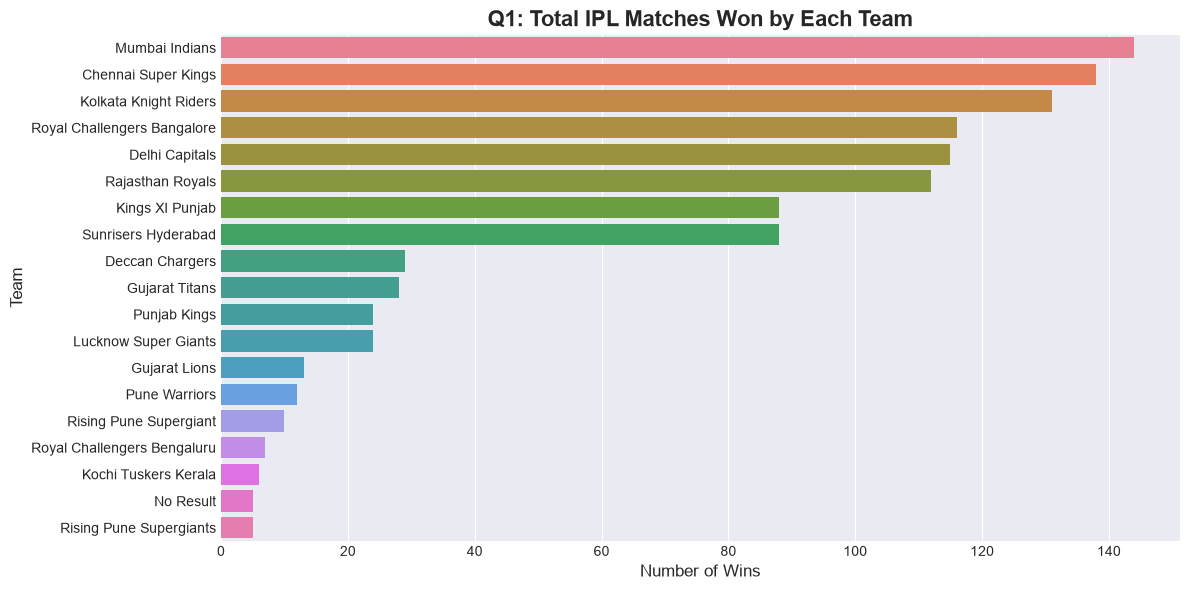

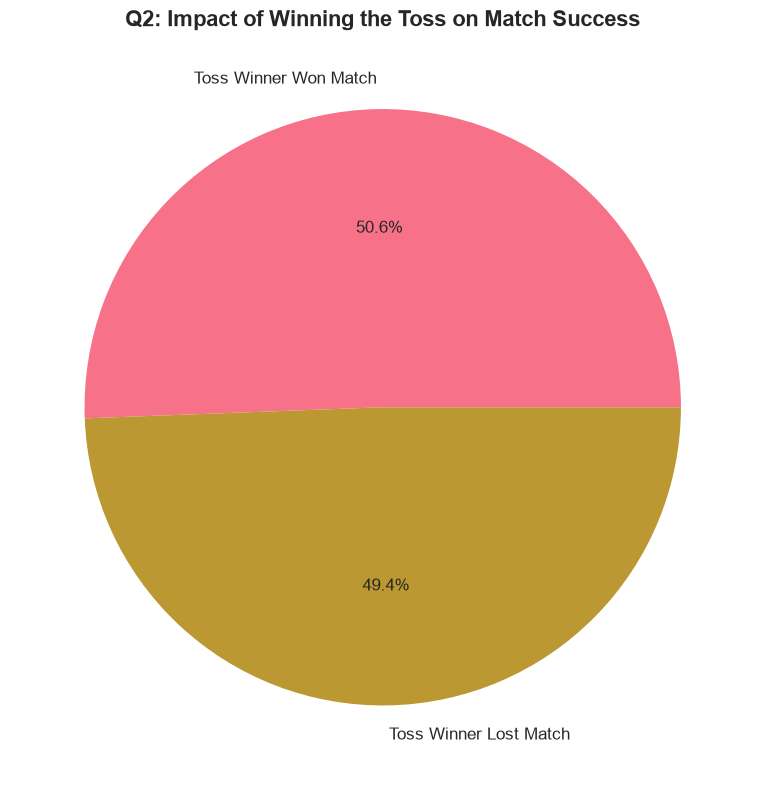

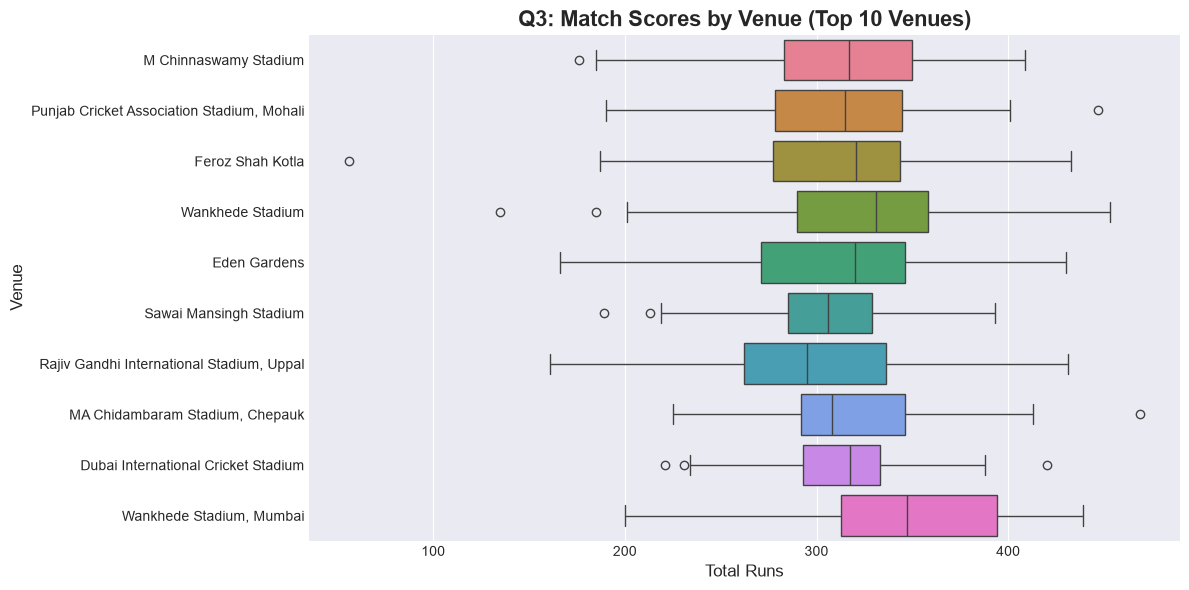

In [6]:
# Q1: Which team has won the most IPL matches overall?
fig, ax = plt.subplots(figsize=(12, 6))
win_counts = matches['winner'].value_counts()
sns.barplot(x=win_counts.values, y=win_counts.index, hue=win_counts.index, legend=False, ax=ax)

ax.set_title('Q1: Total IPL Matches Won by Each Team', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Wins', fontsize=12)
ax.set_ylabel('Team', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/q1_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()

# Q2: How does toss winning affect match winning?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_match_winner'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(toss_impact, labels=['Toss Winner Won Match', 'Toss Winner Lost Match'], autopct='%1.1f%%', textprops={'fontsize': 12})
ax.set_title('Q2: Impact of Winning the Toss on Match Success', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/q2_toss_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Q3: Which venues produce the highest-scoring matches?
match_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
match_venues = match_runs.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
top_venues = match_venues['venue'].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='total_runs', y='venue', data=match_venues[match_venues['venue'].isin(top_venues)], hue='venue', legend=False, ax=ax)

ax.set_title('Q3: Match Scores by Venue (Top 10 Venues)', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_ylabel('Venue', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/q3_venues.png', dpi=150, bbox_inches='tight')
plt.show()

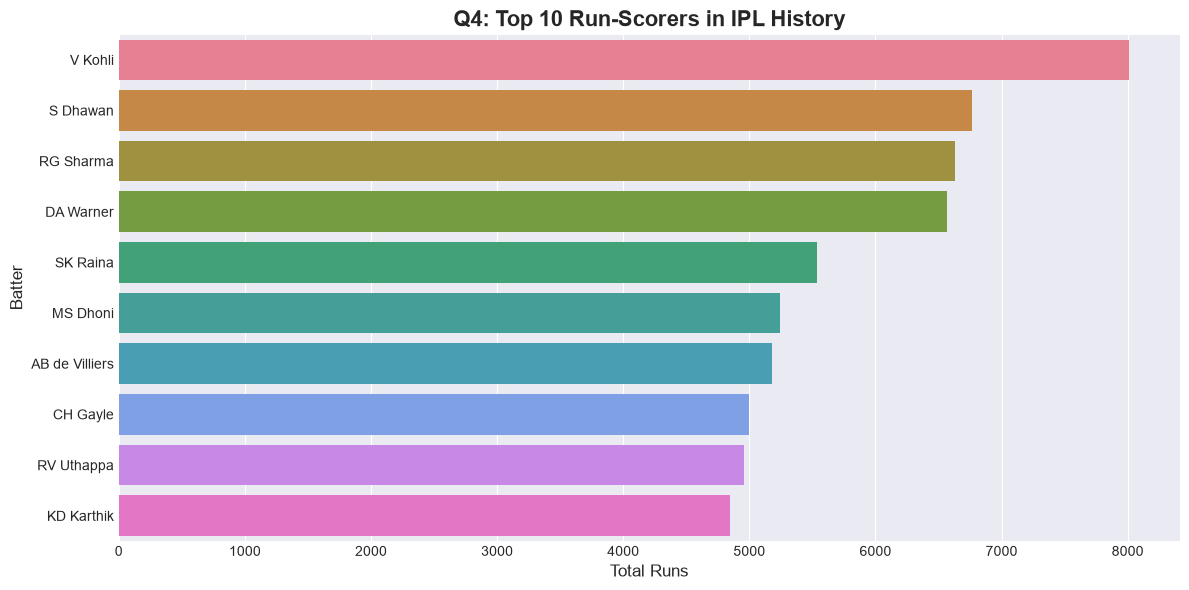

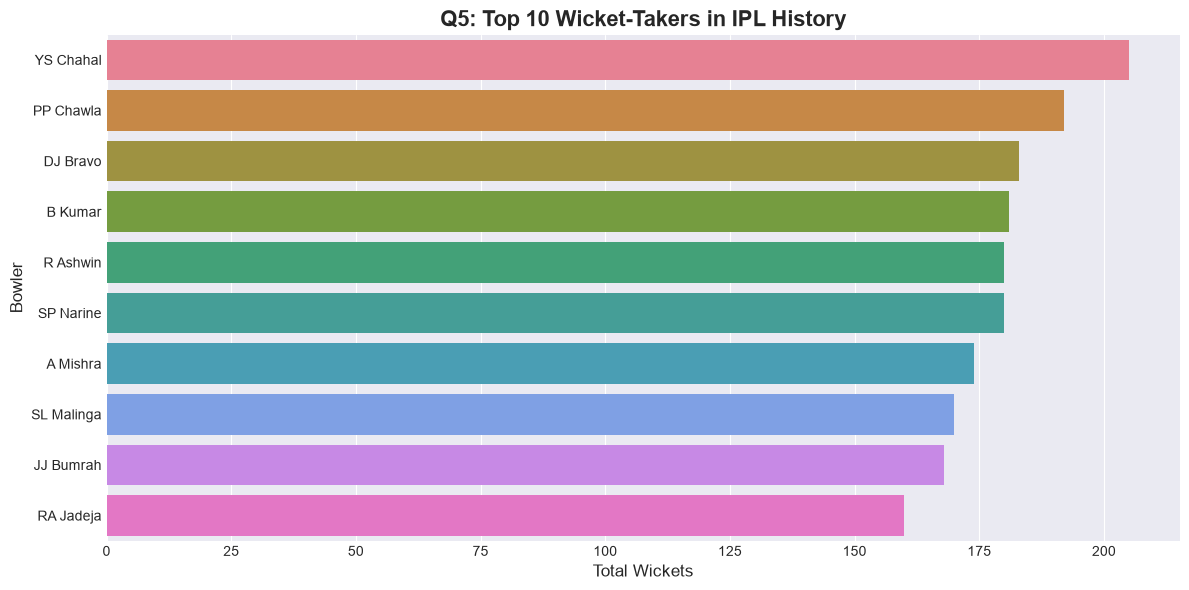

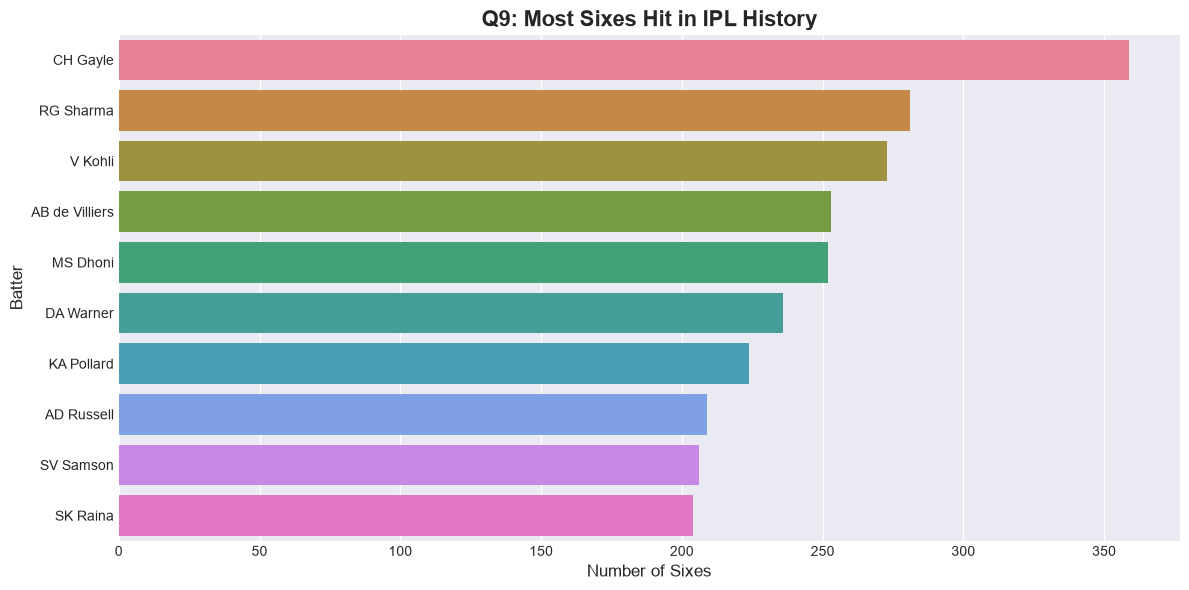

In [7]:
# Handle column name variations between older and newer IPL datasets
batter_col = 'batter' if 'batter' in deliveries.columns else 'batsman'
runs_col = 'batsman_runs' if 'batsman_runs' in deliveries.columns else 'batter_runs'

# Q4: Who are the top 10 run-scorers in IPL history?
top_batsmen = deliveries.groupby(batter_col)[runs_col].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, hue=top_batsmen.index, legend=False, ax=ax)

ax.set_title('Q4: Top 10 Run-Scorers in IPL History', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_ylabel('Batter', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/q4_top_run_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

# Q5: Who are the top 10 wicket-takers?
wickets = deliveries[deliveries['dismissal_kind'].notna()]
wickets = wickets[~wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = wickets.groupby('bowler')['player_dismissed'].count().nlargest(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, hue=top_bowlers.index, legend=False, ax=ax)

ax.set_title('Q5: Top 10 Wicket-Takers in IPL History', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_ylabel('Bowler', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/q5_top_wicket_takers.png', dpi=150, bbox_inches='tight')
plt.show()

# Q9: Who has hit the most sixes in IPL history?
sixes = deliveries[deliveries[runs_col] == 6]
top_six_hitters = sixes[batter_col].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_six_hitters.values, y=top_six_hitters.index, hue=top_six_hitters.index, legend=False, ax=ax)

ax.set_title('Q9: Most Sixes Hit in IPL History', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Sixes', fontsize=12)
ax.set_ylabel('Batter', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/q9_most_sixes.png', dpi=150, bbox_inches='tight')
plt.show()

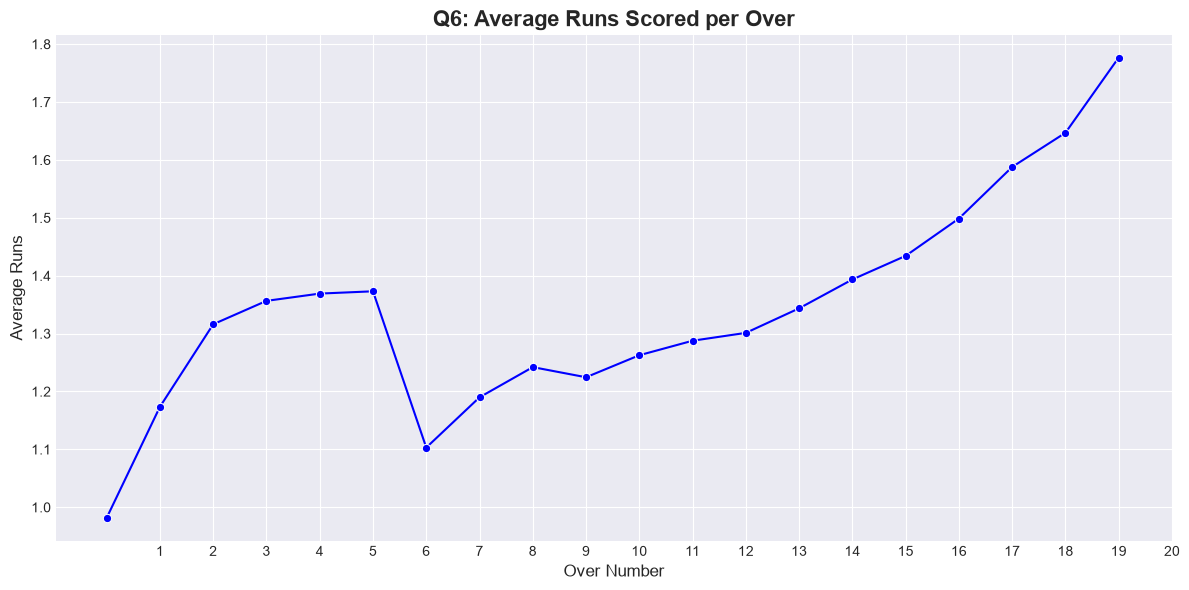

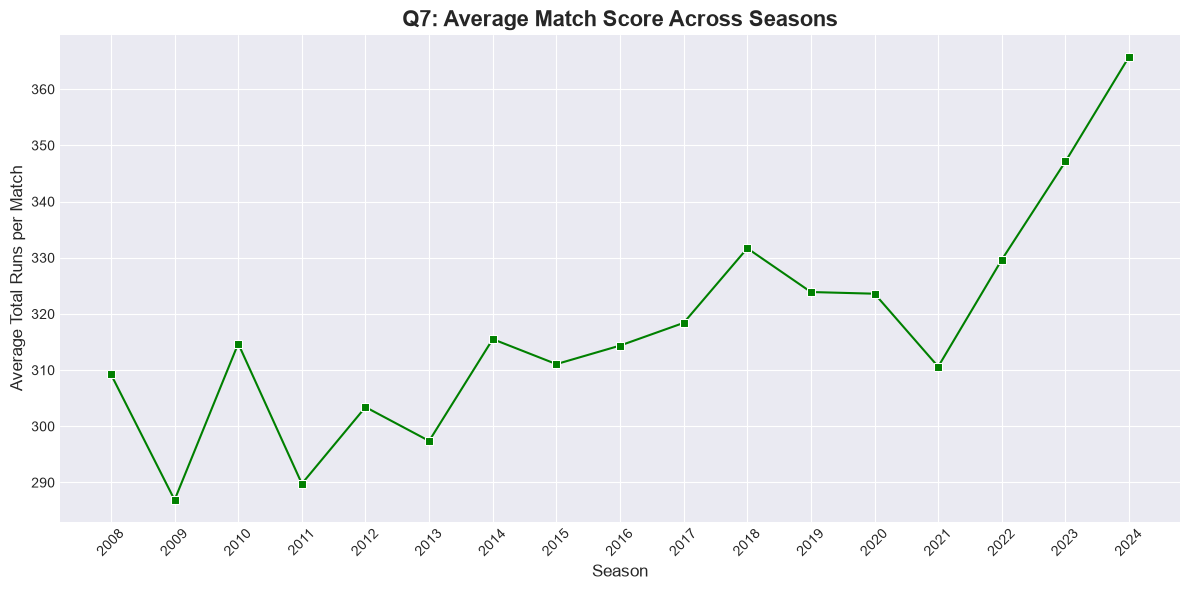

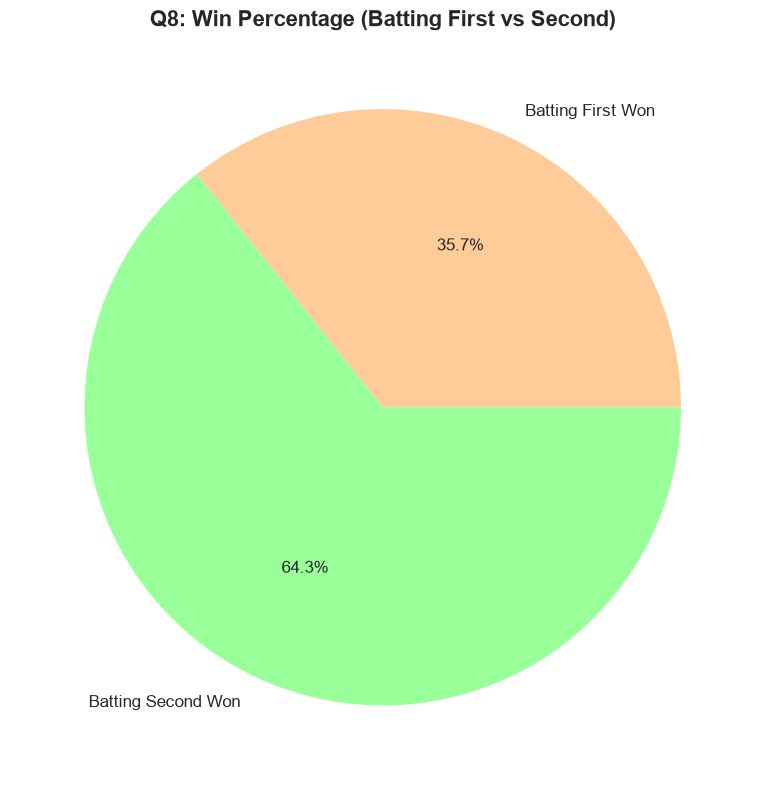

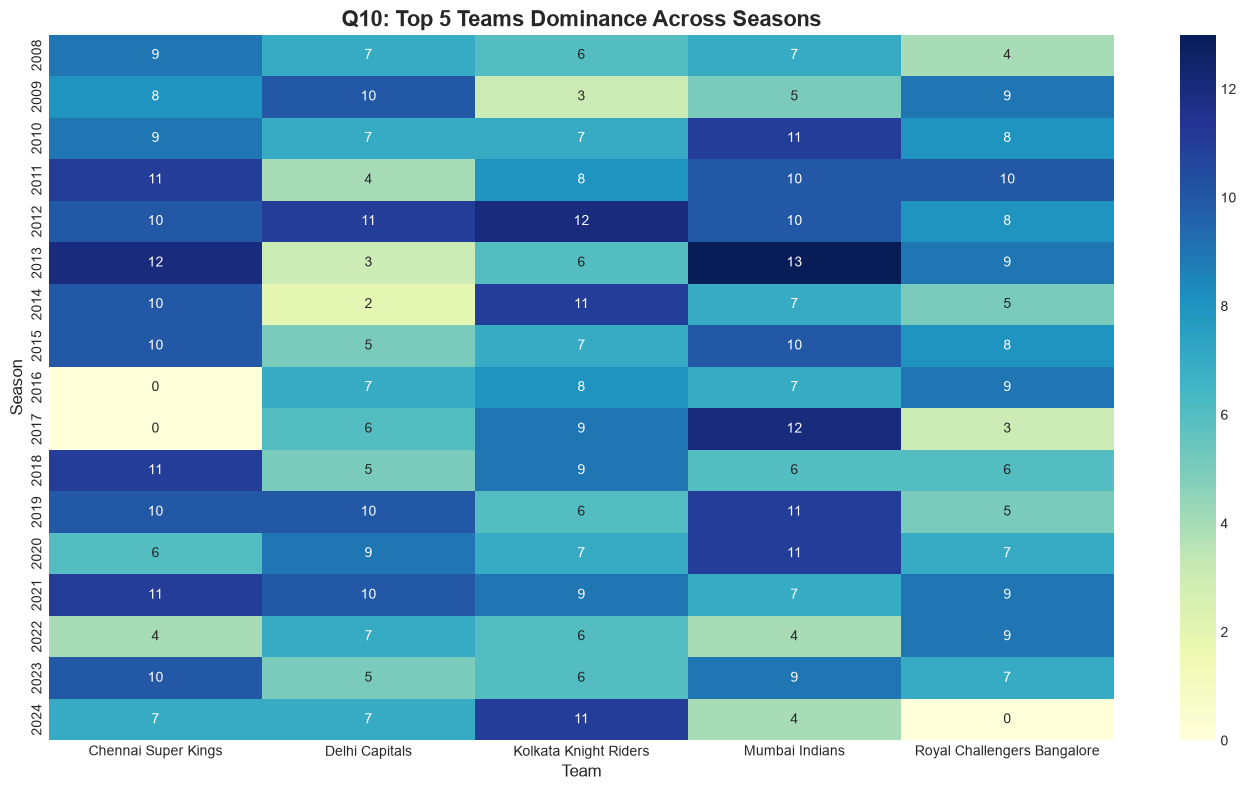

In [8]:
# ==========================================
# Q6: How many runs are typically scored in each over?
# ==========================================
over_runs = deliveries.groupby('over')['total_runs'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=over_runs.index, y=over_runs.values, marker='o', color='b', ax=ax)

ax.set_title('Q6: Average Runs Scored per Over', fontsize=16, fontweight='bold')
ax.set_xlabel('Over Number', fontsize=12)
ax.set_ylabel('Average Runs', fontsize=12)
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.savefig('../visuals/q6_runs_per_over.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# Q7: Which season had the highest average match scores?
# ==========================================
match_runs_local = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
season_runs = match_runs_local.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
avg_season_scores = season_runs.groupby('season')['total_runs'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=avg_season_scores.index, y=avg_season_scores.values, marker='s', color='g', ax=ax)

ax.set_title('Q7: Average Match Score Across Seasons', fontsize=16, fontweight='bold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Average Total Runs per Match', fontsize=12)
ax.set_xticks(avg_season_scores.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../visuals/q7_season_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# Q8: What is the win percentage of teams batting first vs second?
# ==========================================
if 'win_by_runs' in matches.columns and 'win_by_wickets' in matches.columns:
    bat_first_wins = (matches['win_by_runs'] > 0).sum()
    bat_second_wins = (matches['win_by_wickets'] > 0).sum()
elif 'won_by' in matches.columns:
    bat_first_wins = (matches['won_by'].str.lower() == 'runs').sum()
    bat_second_wins = (matches['won_by'].str.lower() == 'wickets').sum()
else:
    bat_first_wins = (matches['toss_decision'] == 'bat').sum()
    bat_second_wins = (matches['toss_decision'] == 'field').sum()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie([bat_first_wins, bat_second_wins], labels=['Batting First Won', 'Batting Second Won'], autopct='%1.1f%%', colors=['#ffcc99','#99ff99'], textprops={'fontsize': 12})

ax.set_title('Q8: Win Percentage (Batting First vs Second)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/q8_batting_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# Q10: How has team dominance changed across seasons?
# ==========================================
clean_winners = matches[matches['winner'] != 'No Result']
top_5_teams = clean_winners['winner'].value_counts().head(5).index
top_5_matches = clean_winners[clean_winners['winner'].isin(top_5_teams)]
team_season_wins = pd.crosstab(top_5_matches['season'], top_5_matches['winner'])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(team_season_wins, cmap='YlGnBu', annot=True, fmt='d', ax=ax)

ax.set_title('Q10: Top 5 Teams Dominance Across Seasons', fontsize=16, fontweight='bold')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Season', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/q10_team_dominance.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import os
print("Python is looking for the visuals folder here:")
print(os.path.abspath('../visuals'))

print("\nFiles actually inside that folder:")
if os.path.exists('../visuals'):
    print(os.listdir('../visuals'))
else:
    print("The folder does not exist at this path!")

Python is looking for the visuals folder here:
C:\Users\Nagendraprasad\IPL-Data-Exploratory-Analysis-Dashboard\visuals

Files actually inside that folder:
['.gitkeep', 'q10_team_dominance.png', 'q1_team_wins.png', 'q2_toss_impact.png', 'q3_venues.png', 'q4_top_run_scorers.png', 'q5_top_wicket_takers.png', 'q6_runs_per_over.png', 'q7_season_scores.png', 'q8_batting_advantage.png', 'q9_most_sixes.png']
